# Business Overview Dashboard

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.ticker as mtick

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

#Load data
customer_df = pd.read_csv("../data/derived/customer_fact_table.csv")
order_df = pd.read_csv("../data/derived/order_fact_table.csv")
inventory_df = pd.read_csv("../data/derived/product_month_inventory_fact.csv")

## Convert Date Columns

In [2]:
customer_df["signup_date"] = pd.to_datetime(customer_df["signup_date"])
order_df["order_date"] = pd.to_datetime(order_df["order_date"])
inventory_df["snapshot_month"] = pd.to_datetime(inventory_df["snapshot_month"])

## Monthly Summary Tables

In [3]:
# 1. Monthly Signups
monthly_signups = customer_df.groupby(
    customer_df["signup_date"].dt.to_period("M")
).size().reset_index(name="signups")

monthly_signups["signup_date"] = monthly_signups["signup_date"].dt.to_timestamp()

# 2. Monthly Orders
monthly_orders = order_df.groupby(
    order_df["order_date"].dt.to_period("M")
).size().reset_index(name="orders")

monthly_orders["order_date"] = monthly_orders["order_date"].dt.to_timestamp()

# 3. Monthly Sales
monthly_sales = order_df.groupby(
    order_df["order_date"].dt.to_period("M")
)["net_revenue"].sum().reset_index()

monthly_sales["order_date"] = monthly_sales["order_date"].dt.to_timestamp()

# 4. Monthly Stockout Prevalence
monthly_stockout = inventory_df.groupby(
    inventory_df["snapshot_month"].dt.to_period("M")
)["stockout_flag"].mean().reset_index()

monthly_stockout["snapshot_month"] = monthly_stockout["snapshot_month"].dt.to_timestamp()

## Plot Overview Dashboard

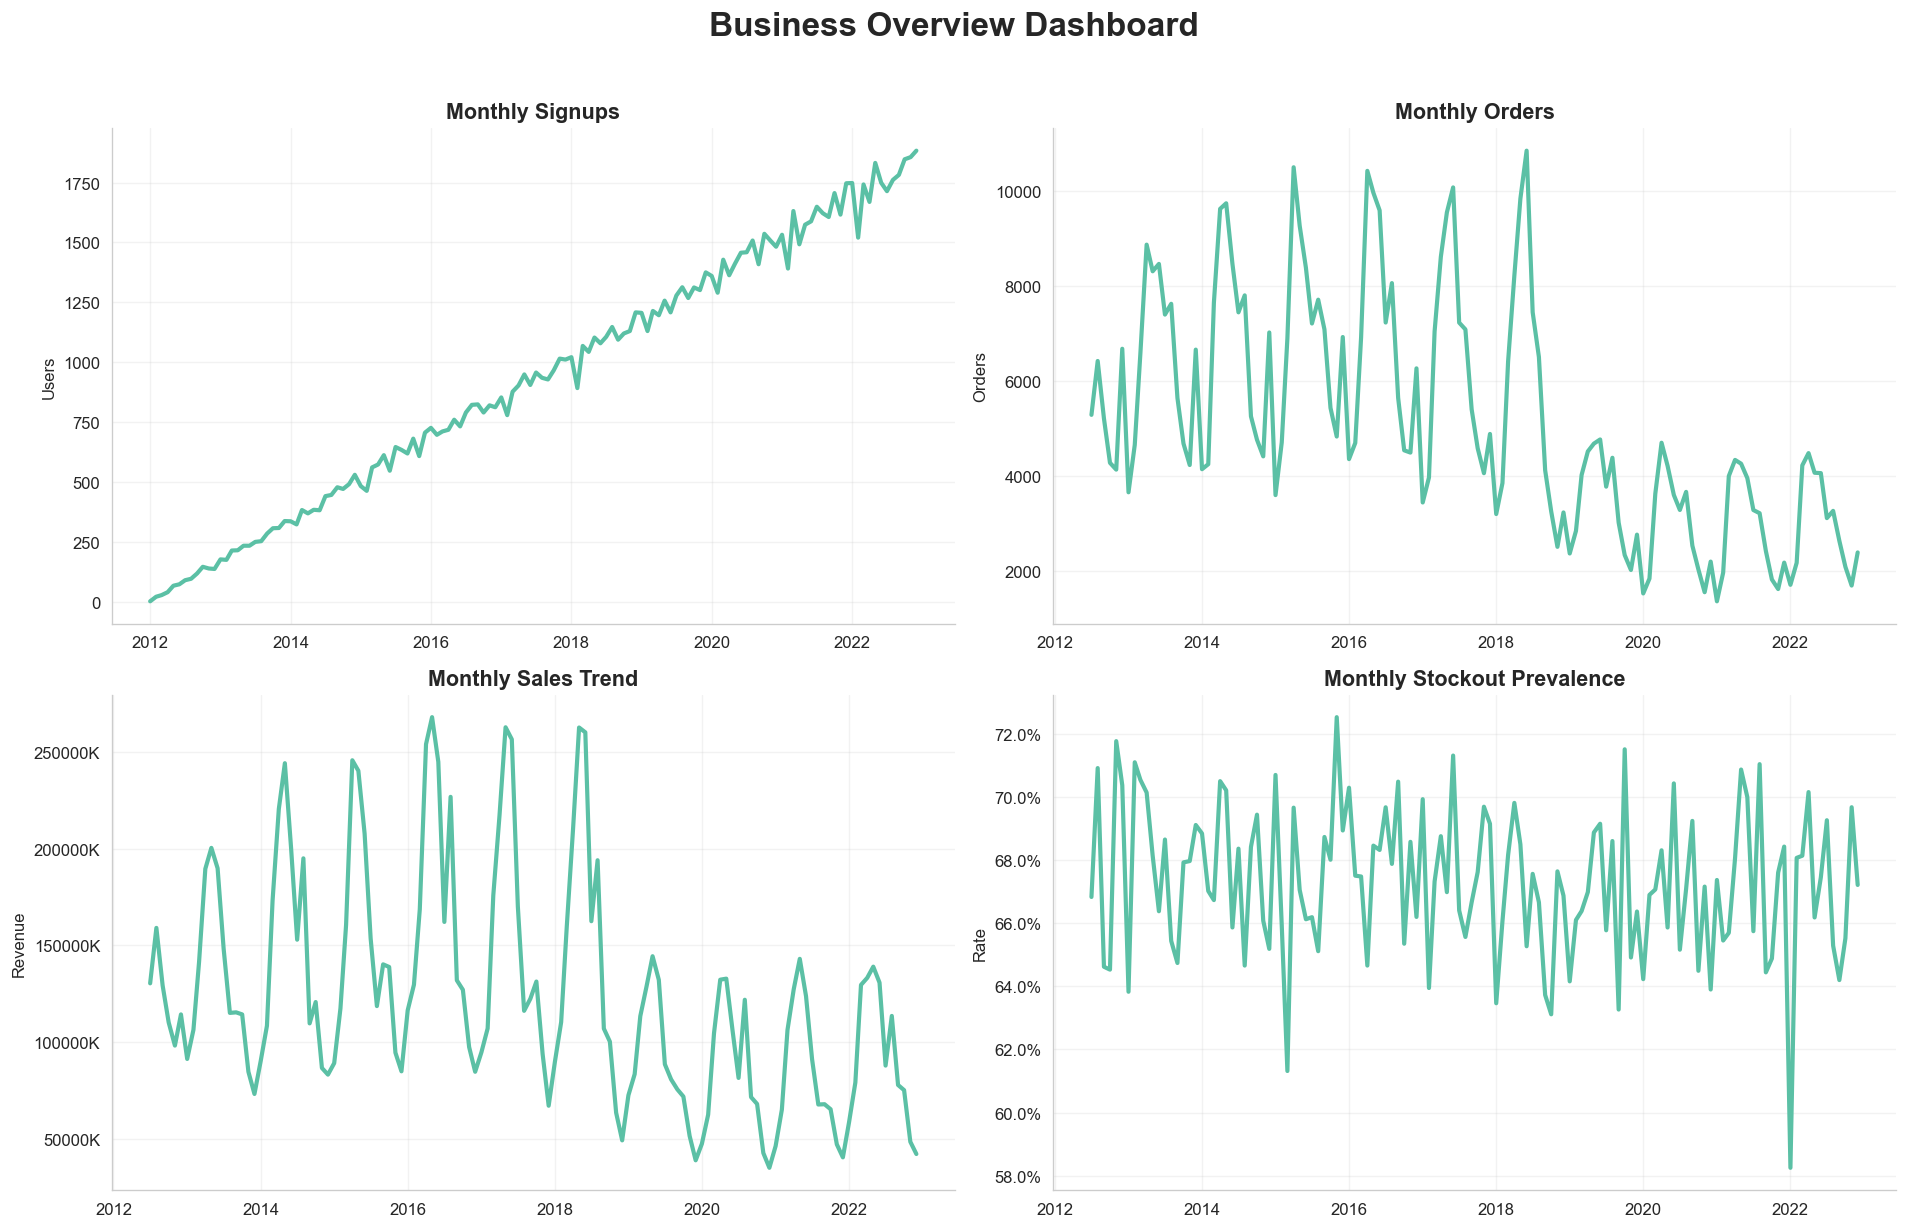

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))
fig.suptitle("Business Overview Dashboard", fontsize=20, weight="bold", y=1.02)

main_color = "#5BC0A5"   

# Chart 1: Monthly Signups
sns.lineplot(
    data=monthly_signups,
    x="signup_date",
    y="signups",
    linewidth=2.5,
    color=main_color,
    ax=axes[0,0]
)
axes[0,0].set_title("Monthly Signups", fontsize=13, weight="bold")
axes[0,0].set_ylabel("Users")
axes[0,0].set_xlabel("")

# Chart 2: Monthly Orders
sns.lineplot(
    data=monthly_orders,
    x="order_date",
    y="orders",
    linewidth=2.5,
    color=main_color,
    ax=axes[0,1]
)
axes[0,1].set_title("Monthly Orders", fontsize=13, weight="bold")
axes[0,1].set_ylabel("Orders")
axes[0,1].set_xlabel("")

# Chart 3: Monthly Sales
sns.lineplot(
    data=monthly_sales,
    x="order_date",
    y="net_revenue",
    linewidth=2.5,
    color=main_color,
    ax=axes[1,0]
)
axes[1,0].set_title("Monthly Sales Trend", fontsize=13, weight="bold")
axes[1,0].set_ylabel("Revenue")
axes[1,0].set_xlabel("")
axes[1,0].yaxis.set_major_formatter(
    mtick.FuncFormatter(lambda x, p: f'{x/1000:.0f}K')
)

# Chart 4: Monthly Stockout
sns.lineplot(
    data=monthly_stockout,
    x="snapshot_month",
    y="stockout_flag",
    linewidth=2.5,
    color=main_color,
    ax=axes[1,1]
)
axes[1,1].set_title("Monthly Stockout Prevalence", fontsize=13, weight="bold")
axes[1,1].set_ylabel("Rate")
axes[1,1].set_xlabel("")
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))


for ax in axes.flat:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))   # mỗi 2 năm
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis="x", rotation=0)


    ax.grid(True, alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Business Overview Insights

### 1. Monthly Signups
Số lượng người đăng ký tăng đều và khá ổn định theo thời gian, không có dấu hiệu suy giảm.
=> Hoạt động thu hút khách hàng đang vận hành hiệu quả và duy trì tốt. Tuy nhiên, tốc độ tăng trưởng mang tính tuyến tính cho thấy doanh nghiệp chưa tạo được cú hích tăng trưởng mạnh từ các chiến dịch lớn.

### 2. Monthly Orders
Số lượng đơn hàng biến động mạnh và không tăng tương ứng với tốc độ tăng của người đăng ký, ở cuối kỳ tốc độ có xu hướng giảm.
=> Doanh nghiệp đang gặp vấn đề ở giai đoạn kích hoạt/chuyển đổi. Tăng trưởng người dùng chưa được chuyển hóa thành tăng trưởng mua hàng. Có dấu hiệu tồn tại khoảng cách giữa đăng ký và hành vi mua thực tế.

### 3. Monthly Sales Trend
Doanh thu dao động lớn giữa các tháng, xuất hiện nhiều đợt tăng ngắn hạn nhưng thiếu ổn định. Cuối kỳ có xu hướng giảm nhẹ.
=> Doanh thu hiện phụ thuộc vào các chiến dịch ngắn hạn (promotion/campaign), chưa hình thành nguồn doanh thu lặp lại bền vững.

### 4. Monthly Stockout Prevalence
Tỷ lệ hết hàng duy trì ở mức cao và chưa có cải thiện rõ ràng.
=> Đang bị một điểm nghẽn về vận hành ở chuỗi cung ứng. Doanh nghiệp có khả năng đang mất doanh thu do không đủ hàng để đáp ứng nhu cầu thị trường.

## Tổng quan vấn đề

Bức tranh chung cho thấy doanh nghiệp thu hút được nhiều khách hàng mới, nhưng chưa chuyển đổi hiệu quả thành đơn hàng và doanh thu ổn định. Đồng thời, tình trạng hết hàng kéo dài cho thấy khả năng đáp ứng nhu cầu cũng còn hạn chế.

Điều này đặt ra hai bài toán trọng tâm:

Demand side: Vì sao người dùng đăng ký nhưng không tiếp tục mua hàng?
Supply side: Vì sao nhu cầu tồn tại nhưng doanh nghiệp chưa phục vụ tốt?